## Transfer Learning Model CNN

# **1. Pendahuluan**

Di praktikum 5 ini, praktikan akan mengimplementasikan model CNN yang sudah dilatih menggunakan dataset ImageNet untuk diterapkan pada kasus klasifikasi citra dengan dataset baru. Cara ini disebut juga dengan transfer learning. Transfer learning pada intinya adalah menggunakan model yang telah ditraining pada dataset tertentu untuk melakukan klasifikasi pada kasus yang baru.

Salah satu praktik yang umum dilakukan adalah menggunakan dataset yang kecil untuk membangun pre-trained network. Hirarki fitur spasial akan bertindak sebagai model generik bagi dunia visual kita. Ini akan terbukti sangat berguna dan dapat digunakan kembali dengan mudah. Contohnya sesorang mungkin menggunakan dataset ImageNet kemudian menggunakannya untuk tujuan yang berbeda, misalnya Deteksi Furnitur IKEA.

Dalam praktikum ini, kita akan menggunakan Convolutional Network yang besar dan ditraining pada ImageNet dataset (1.4 juta gambar berlabel dan 1000 kelas yang berbeda). ImageNet memiliki kelas animal (hewan). Namun kita akan gunakan untuk klasifikasi kcuing dan anjing.

Ada 3 model CNN yang akan digunakan yaitu:
1. VGG16
2. ResNet50
3. MobileNetV2

## Preview Arsitektur Model
## VGG16
![VGG16](https://iq.opengenus.org/content/images/2019/01/vgg_layers.png)
## ResNet50
![ResNet50](https://www.researchgate.net/publication/349646156/figure/fig4/AS:995806349897731@1614430143429/The-architecture-of-ResNet-50-vd-a-Stem-block-b-Stage1-Block1-c-Stage1-Block2.png)
## MobileNetV2
![MobileNetV2](https://miro.medium.com/max/1016/1*5iA55983nBMlQn9f6ICxKg.png)

# **2. Mounting Google Drive**

In [ ]:
from google.colab import drive

# mounting dataset dari gdrive
drive.mount('/content/gdrive', force_remount=True)

# lokasi dataset - ubah sesuai dengan lokasi anda mengupload folder datanya
# folder ini juga digunakan untuk menyimpan model yang sudah dilatih
root_path = 'gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/'

# opsional - tampilkan info lokasi dataset
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/


# **3. Download Dataset**
Download dataset dan simpan di gdrive yang sudah disediakan.
Kita menggunakan Flower Dataset yang terdiri 5 kelas yaitu daisy, dandelion, roses, sunflowers, dan tulips.

In [ ]:
import os
import shutil
from six.moves import urllib
from os.path import join, exists

# lokasi gdrive untuk menyimpan dataset
FLOWERS_TGZ = join(root_path, 'flower_photos.tgz')
FLOWERS_DIR = join(root_path, 'flower_photos/')

# fungsi untuk mendownload dataset dan simpan di gdrive yang sudah disediakan
def download_images():
    # Ensure that the path exists before attempting to write to it
    os.makedirs(root_path, exist_ok=True)  # Create directories if they don't exist

    if not exists(FLOWERS_DIR):
        DOWNLOAD_URL = 'http://download.tensorflow.org/example_images/flower_photos.tgz'
        print('Mendownload dataset dari alamat %s...' % DOWNLOAD_URL)
        urllib.request.urlretrieve(DOWNLOAD_URL, FLOWERS_TGZ)
        shutil.unpack_archive(FLOWERS_TGZ, root_path)
        print('Flower dataset berhasil disimpan')
    else:
        print('Flower dataset sudah ada di gdrive anda')

# download dataset
download_images()

Flower dataset sudah ada di gdrive anda


# **4. Baca dan Split Dataset**
Baca dataset flower kemudian split dataset menjadi data latih, data validasi dan data uji.

In [ ]:
import random
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

TRAIN_FRACTION = 0.8
RANDOM_SEED = 2018

# fungsi untuk split dataset menjadi data latih dan data uji
# resize juga citra dalam dataset tersebut menjadi ukuran (224,224,3)
def make_train_test_set(input_size=(224, 224, 3)):
    train_data, train_label, test_data, test_label = [], [], [], []
    shuffler = random.Random(RANDOM_SEED)

    # ambil folder yang ada didalam dataset
    (path_dirs, list_dirs, _) = next(os.walk(FLOWERS_DIR))
    list_dirs.sort()

    # folder -> nama kelas
    for i in range(len(list_dirs)):
        file_dir = join(path_dirs, list_dirs[i])
        (_, _, filenames) = next(os.walk(file_dir))

        # acak data citranya
        filenames.sort()
        shuffler.shuffle(filenames)

        # tentukan rasio data latih dan data uji
        num_train = int(len(filenames) * TRAIN_FRACTION)

        # bagi dataset menjadi data latih dan data uji
        for j in range(len(filenames)):
            file_name = join(file_dir, filenames[j])

            # baca citra
            bgr_img = cv2.imread(file_name)
            rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

            # resize ukuran citra agar seragam
            res_img = cv2.resize(rgb_img, (input_size[0], input_size[1]))

            # bagi kedalam data latih atau data uji secara acak
            if j < num_train:
                train_data.append(res_img)
                train_label.append(i)
            else:
                test_data.append(res_img)
                test_label.append(i)

    # konversi ke numpy array
    train_data = np.array(train_data)
    train_label = np.array(train_label)
    test_data = np.array(test_data)
    test_label = np.array(test_label)

    return train_data, test_data, train_label, test_label, list_dirs

# split dataset menjadi data latih dan data uji
X_data, X_test, y_data, y_test, class_name = make_train_test_set()

# bagi data latih untuk mendapatkan data validasi dengan rasio 70% - 30%
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data,
                                                  test_size=0.3,
                                                  random_state=42)
# tampilkan informasi dataset
num_class = len(class_name)
print('Jumlah kelas:', num_class)
print('Label kelas:', class_name)
print('Dimensi data latih:', X_train.shape)
print('Dimensi data validasi:', X_val.shape)
print('Dimensi data uji:', X_test.shape)

Jumlah kelas: 5
Label kelas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Dimensi data latih: (2053, 224, 224, 3)
Dimensi data validasi: (881, 224, 224, 3)
Dimensi data uji: (736, 224, 224, 3)


## Tampilkan Sampel Dataset

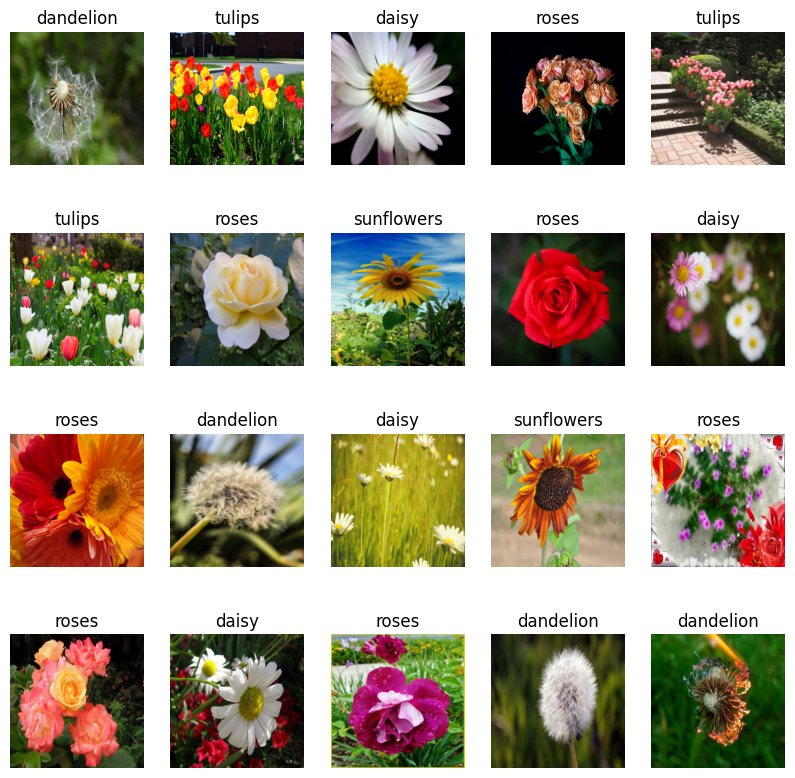

In [ ]:
import matplotlib.pyplot as plt

# tampilkan misalnya 20 citra pada dataset
nimages = 20
ncols_plot = 5
nrows_plot = nimages//ncols_plot

plot_frame = plt.figure(figsize=(10,10))
for i in range(nimages):
    ax = plot_frame.add_subplot(nrows_plot, ncols_plot, i+1)
    ax.axis('off')
    ax.set_title(class_name[y_train[i]])
    plt.imshow(np.uint8(X_train[i]))

# **5. Membuat Augmentasi Data**
Perbaiki kode berikut agar pada data latih dilakukan augmentasi data sebagai berikut:
1. Lakukan scaling pada nilai pixel input citra sehingga menjadi rentang 0-1
2. Lakukan rotasi secara random dalam rentang 20 derajat
3. Lakukan horizontal flipping


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# input citra
input_size = (224, 224, 3)

# ukuran batch
batch_size = 32

# inisialisasi generator data latih dengan augmentasi data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# input citra
input_size = (224, 224, 3)

# ukuran batch
batch_size = 32

# inisialisasi generator data latih dengan augmentasi data
train_datagen = ImageDataGenerator(
    rescale=1./255,         # lakukan rescale agar piksel input citra berada pada rentang 0-1
    rotation_range=20,      # lengkapi kode, lakukan rotasi rentang 20 derajat
    horizontal_flip=True    # lengkapi kode, flipping horizontal
)
# inisialisasi generator data validasi
val_datagen = ImageDataGenerator(rescale=1./255)
# inisialisasi generator data uji
test_datagen = ImageDataGenerator(rescale=1./255)

# buat generator data latih
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size,
                                     shuffle=True)
# buat generator data validasi
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size,
                                 shuffle=True)
# buat generator data uji
test_generator = test_datagen.flow(X_test, y_test, batch_size=1, shuffle=True)
# inisialisasi generator data validasi
val_datagen = ImageDataGenerator(rescale=1./255)
# inisialisasi generator data uji
test_datagen = ImageDataGenerator(rescale=1./255)

# buat generator data latih
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size,
                                     shuffle=True)
# buat generator data validasi
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size,
                                 shuffle=True)
# buat generator data uji
test_generator = test_datagen.flow(X_test, y_test, batch_size=1, shuffle=True)

# **6. Membangun Model CNN**
Ada 3 pre-trained model dari ImageNet yang akan digunakan di praktikum ini yaitu:
1. VGG16
2. ResNet50
3. MobileNetV2

## 6.1. Pemilihan Model

In [ ]:
from enum import Enum

# nama model yang akan digunakan
class MODEL(Enum):
    TF_VGG16 = 1
    TF_ResNet50 = 2
    TF_MobileNetV2 = 3

# pilih model yang akan digunakan sekarang
# ganti nama model disini untuk mencoba model yang lain
# opt_model = MODEL.TF_VGG16
# opt_model = MODEL.TF_ResNet50
opt_model = MODEL.TF_MobileNetV2

# jumlah epoch pelatihan
epochs = 20

## 6.2. Fungsi Pre-Trained Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2

from tensorflow.keras.callbacks import ModelCheckpoint

Perhatikan bahwa kita memberikan tiga argumen:

* `weights`, menentukan weight checkpoint yang menginisiasi model di awal
* `include_top`, mengikutsertakan  densely-connected classifier pada bagian teratas dari network. Secara default, densely-connected classifier ini akan sesuai dengan 1000 kelas dari dataset ImageNet.
* `input_shape`, bentuk dari input berupa tensor yang akan dimasukkan ke dalam network. Argumen ini sifatnya optional: jika kita tidak memberikan argumen ini, network akan dapat memproses input dengan ukuran berapapun.

In [ ]:
# input layer
inputs = Input(shape=input_size)

# pilih base model
if opt_model == MODEL.TF_VGG16:
    # lokasi untuk menyimpan hasil pelatihan
    checkpoint_filepath = join(root_path, 'lab04_vgg16_model.h5')

    # load base model VGG16 untuk ekstraksi fitur
    base_model = VGG16(include_top=False,
                       weights='imagenet',  # pre-trained dari ImageNet
                       input_shape=input_size)

elif opt_model == MODEL.TF_ResNet50:
    # lokasi untuk menyimpan hasil pelatihan
    checkpoint_filepath = join(root_path, 'lab04_resnet50_model.h5')

    # load base model ResNet50 untuk ekstraksi fitur
    base_model = ResNet50(include_top=False,
                          weights='imagenet',  # pre-trained dari ImageNet
                          input_shape=input_size)

elif opt_model == MODEL.TF_MobileNetV2:
    # lokasi untuk menyimpan hasil pelatihan
    checkpoint_filepath = join(root_path, 'lab04_mobilenetv2_model.h5')

    # load base model MobileNetV2 untuk ekstraksi fitur
    base_model = MobileNetV2(include_top=False,
                             weights='imagenet', # pre-trained dari ImageNet
                             input_shape=input_size)

base_model.summary() # menampilkan summary dari base model yang dipilih

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

### Freezing the base_model
Perhatikan setting `base_model.trainable = False`. Parameter tersebut akan "freeze" nilai bobot-bobot dan bias pada pre-trained model sehingga kita hanya akan men-trainining layer Softmax. Hal ini biasanya melibatkan bobot yang relatif sedikit dan dapat dilakukan dengan cepat dan tanpa memerlukan  dataset yang sangat besar..

Akan tetapi jika Anda memiliki dataset yang besar, transfer learning dapat bekerja dengan lebih baik menggunakan setting`base_model.trainable = True`.Bobot yang telah dilatih sebelumnya  memberikan nilai awal yang sangat baik dan masih dapat disesuaikan lagi melalui training agar lebih sesuai dengan permasalahan/kasus.

In [ ]:
# freeze the base layer
base_model.trainable = False

# tambahkan input ke base model
add_layer = base_model(inputs, training=False)

# flatten layer sebelum masuk ke FC layer
add_layer = Flatten()(add_layer)

In [ ]:
# sesuaikan dengan jumlah kategori luarannya
# output layer: dense -> softmax
output_layer = Dense(num_class, activation='softmax', name='main_model')(add_layer)

# membangun model untuk klasifikasi
main_model = Model(inputs=inputs, outputs=output_layer, name='LabDL04')

# pilih optimizer dan compile modelnya
init_learning_rate = 1e-4
opt_optimizer = Adam(learning_rate=init_learning_rate)
main_model.compile(optimizer=opt_optimizer,
                   loss='sparse_categorical_crossentropy',
                   loss_weights=1.0,
                   metrics=['accuracy'])
main_model.summary() # menampilkan summary dari model yang dibuat

# simpan model yang mendapatkan akurasi validasi tertinggi
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

Model: "LabDL04"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_model (Dense)              │ (None, 5)              │       313,605 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,571,589 (9.81 MB)

 Trainable params: 313,605 (1.20 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **7. Pelatihan Model CNN**

In [ ]:
# mulai pelatihan dengan n epochs
history = main_model.fit(train_generator,
                         batch_size=batch_size,
                         validation_data=val_generator,
                         epochs=epochs,
                         callbacks=[model_checkpoint_callback],
                         verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.5924 - loss: 1.2611
Epoch 1: val_loss improved from inf to 0.56574, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 45s 526ms/step - accuracy: 0.5943 - loss: 1.2545 - val_accuracy: 0.8275 - val_loss: 0.5657
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8931 - loss: 0.3139
Epoch 2: val_loss improved from 0.56574 to 0.51798, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 382ms/step - accuracy: 0.8929 - loss: 0.3141 - val_accuracy: 0.8309 - val_loss: 0.5180
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9361 - loss: 0.1869
Epoch 3: val_loss improved from 0.51798 to 0.51458, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 350ms/step - accuracy: 0.9361 - loss: 0.1869 - val_accuracy: 0.8445 - val_loss: 0.5146
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9638 - loss: 0.1147
Epoch 4: val_loss improved from 0.51458 to 0.50084, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 26s 404ms/step - accuracy: 0.9637 - loss: 0.1147 - val_accuracy: 0.8558 - val_loss: 0.5008
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9676 - loss: 0.1040
Epoch 5: val_loss improved from 0.50084 to 0.49244, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 28s 427ms/step - accuracy: 0.9677 - loss: 0.1038 - val_accuracy: 0.8536 - val_loss: 0.4924
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9815 - loss: 0.0686
Epoch 6: val_loss improved from 0.49244 to 0.49148, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step - accuracy: 0.9815 - loss: 0.0687 - val_accuracy: 0.8536 - val_loss: 0.4915
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9766 - loss: 0.0677
Epoch 7: val_loss did not improve from 0.49148
65/65 ━━━━━━━━━━━━━━━━━━━━ 24s 366ms/step - accuracy: 0.9766 - loss: 0.0677 - val_accuracy: 0.8581 - val_loss: 0.5081
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9861 - loss: 0.0544
Epoch 8: val_loss did not improve from 0.49148
65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 350ms/step - accuracy: 0.9860 - loss: 0.0545 - val_accuracy: 0.8593 - val_loss: 0.5196
Epoch 9/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9900 - loss: 0.0400
Epoch 9: val_loss improved from 0.49148 to 0.48734, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_mobilenetv2_model.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 354ms/step - accuracy: 0.9900 - loss: 0.0400 - val_accuracy: 0.8615 - val_loss: 0.4873
Epoch 10/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9959 - loss: 0.0266
Epoch 10: val_loss did not improve from 0.48734
65/65 ━━━━━━━━━━━━━━━━━━━━ 24s 365ms/step - accuracy: 0.9959 - loss: 0.0267 - val_accuracy: 0.8638 - val_loss: 0.5077
Epoch 11/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9869 - loss: 0.0340
Epoch 11: val_loss did not improve from 0.48734
65/65 ━━━━━━━━━━━━━━━━━━━━ 24s 369ms/step - accuracy: 0.9869 - loss: 0.0340 - val_accuracy: 0.8649 - val_loss: 0.5057
Epoch 12/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9973 - loss: 0.0182
Epoch 12: val_loss did not improve from 0.48734
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 343ms/step - accuracy: 0.9972 - loss: 0.0183 - val_accuracy: 0.8672 - val_loss: 0.5031
Epoch 13/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9948 - loss: 0.0224
Epoch 13: val_loss did not improve f

## Menampilkan statistik pelatihan

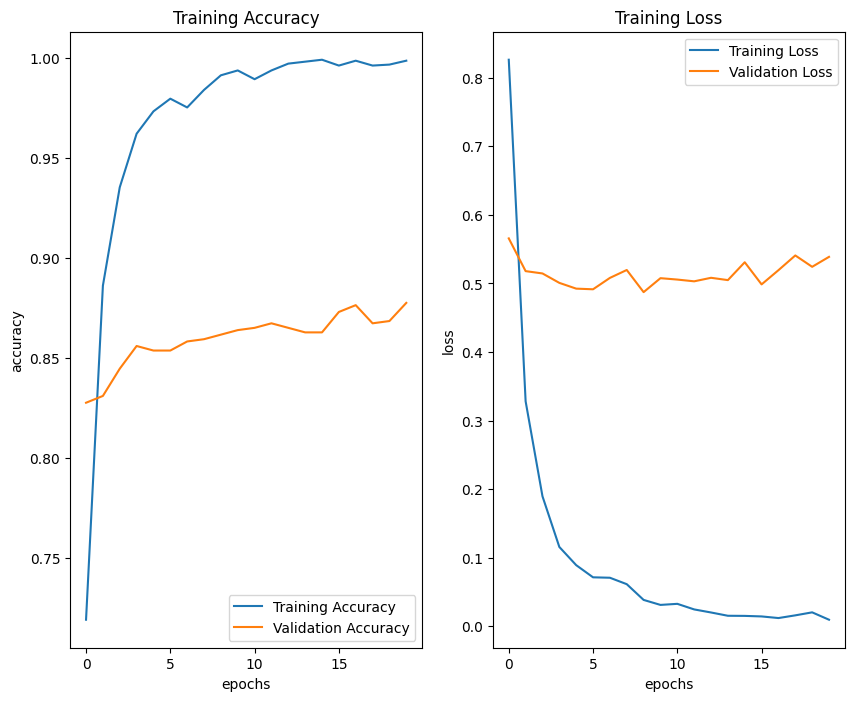

In [ ]:
# ambil statistik pelatihan
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range = range(epochs)

# plot hasil akurasi pelatihan
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.title('Training Accuracy')

# plot hasil loss pelatihan
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Training Loss')
plt.show()

Untuk transfer learning pada model VGG16 dan MobileNetV2 pelatihan dengan 20 epochs sudah cukup untuk mendapatkan akurasi yang tinggi tetapi sering terjadi overfitting akan tetapi untuk model ResNet50 akan perlu epochs yang lebih banyak.

# **8. Evaluasi Model**

In [ ]:
from tensorflow.keras.models import load_model

# load hasil pelatihan untuk di uji
trained_model = load_model(checkpoint_filepath)

# pengujian dengan data uji
trained_model.evaluate(test_generator, verbose=1)

736/736 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8662 - loss: 0.4795


[0.4480428695678711, 0.8777173757553101]

## 8.1. Tampilkan Hasil Pengujian

  0%|          | 0/736 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━

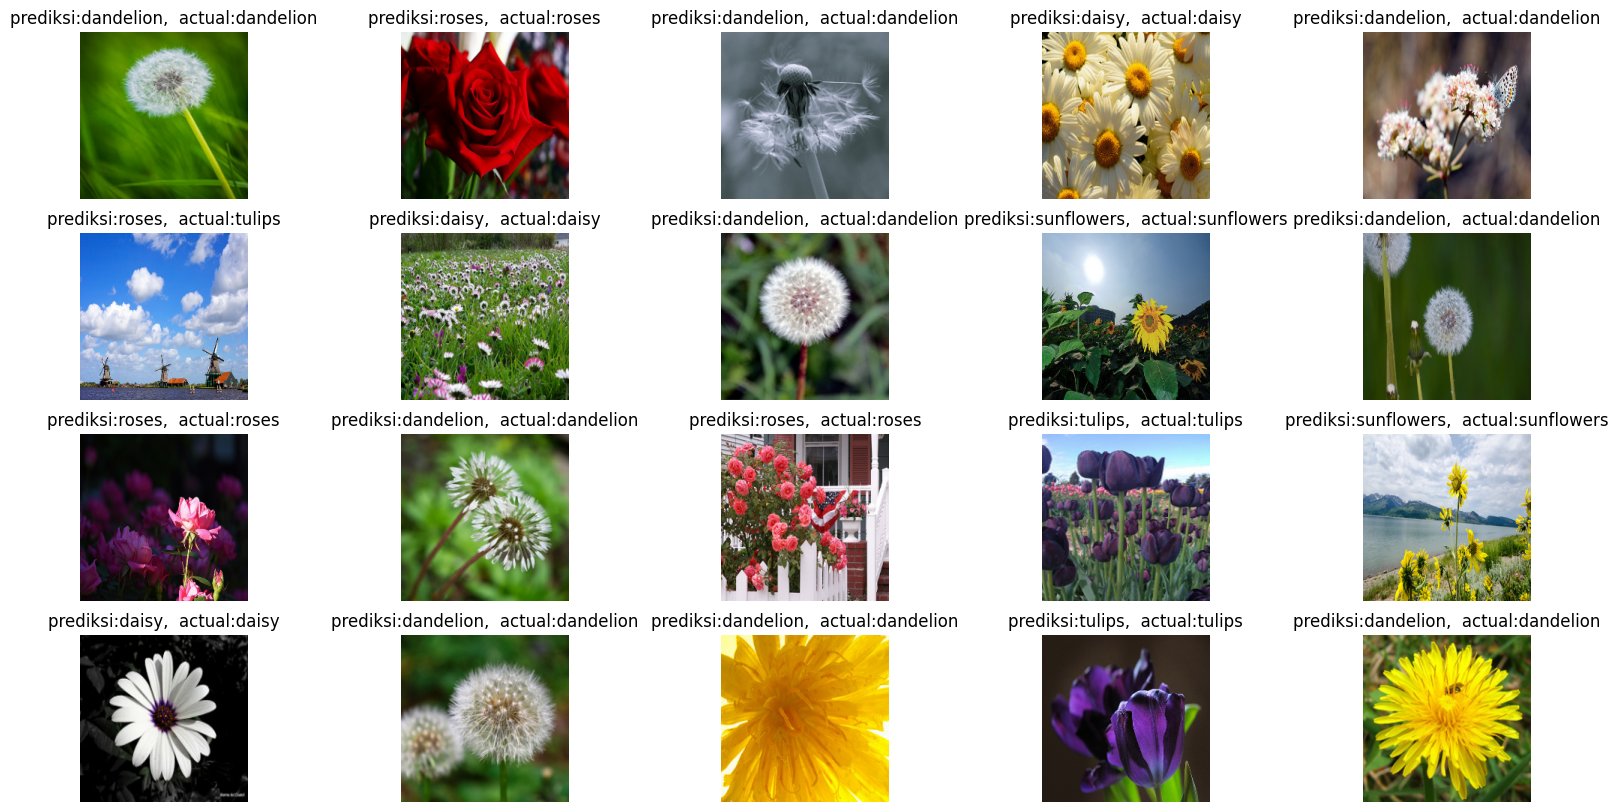

In [ ]:
from tqdm.notebook import tqdm_notebook

# tampilkan misalnya 20 citra pada dataset
nimages = 20
ncols_plot = 5
nrows_plot = nimages//ncols_plot

y_predict = []
y_actual = []
count_imgs = 0
plot_frame = plt.figure(figsize=(20,10))

# one-by-one prediction
for i in tqdm_notebook(range(len(test_generator))):
    imgs, labels = next(test_generator)
    labels = np.array(labels, dtype=np.uint8)
    for j in range(len(imgs)):
        X_batch = np.expand_dims(imgs[j], axis=0)
        prediction_scores = trained_model.predict(X_batch)
        score = np.argmax(prediction_scores)
        y_predict.append(score)
        y_actual.append(labels[j])

        # tampilkan 20 hasil pengujian
        if (count_imgs < nimages):
            ax = plot_frame.add_subplot(nrows_plot, ncols_plot, count_imgs+1)
            ax.axis('off')
            ax.set_title("prediksi:" + class_name[score] + \
                        ",  actual:" + class_name[labels[j]])
            plt.imshow(np.uint8(imgs[j]*255))
        count_imgs += 1

y_predict = np.array(y_predict)
y_actual = np.array(y_actual)

## 8.2. Membuat Confusion Matrix

Laporan Klasifikasi Data Uji:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       127
           1       0.90      0.94      0.92       180
           2       0.81      0.87      0.84       129
           3       0.96      0.85      0.90       140
           4       0.85      0.83      0.84       160

    accuracy                           0.88       736
   macro avg       0.88      0.88      0.88       736
weighted avg       0.88      0.88      0.88       736

Confusion Matrix:
[[113   8   2   1   3]
 [  6 169   1   2   2]
 [  2   0 112   1  14]
 [  4   6   6 119   5]
 [  4   5  17   1 133]]


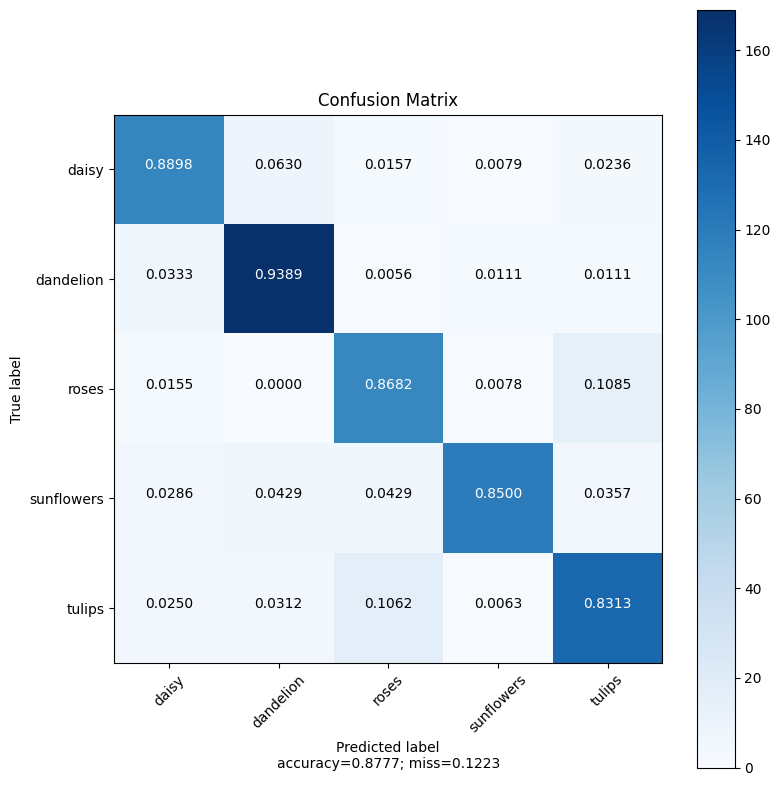

In [ ]:
import itertools
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# cetak laporan hasil klasifikasi data uji
print('Laporan Klasifikasi Data Uji:')
print(classification_report(y_actual, y_predict))

# hitung confusion matrixnya
conf_mat_result = confusion_matrix(y_actual, y_predict)

# cetak confusion matrix
print('Confusion Matrix:')
print(conf_mat_result)

accuracy = np.trace(conf_mat_result) / np.sum(conf_mat_result).astype('float')
misclass = 1 - accuracy

# masukkan nama kelas di dataset
target_names = class_name
plt.figure(figsize=(8, 8))
cmap = plt.get_cmap('Blues')

plt.imshow(conf_mat_result, interpolation='nearest', cmap=cmap)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)

cm = conf_mat_result.astype('float') / conf_mat_result.sum(axis=1)[:, np.newaxis]
thresh = cm.max() / 1.5
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, "{:0.4f}".format(cm[i, j]),
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label\naccuracy={:0.4f}; miss={:0.4f}'.format(accuracy, misclass))
plt.show()

# **9. Post Test**
1.	Ubah kembali pilihan model di langkah nomor 14 pada instruksi praktikum menjadi model VGG16 atau MobileNetV2 (pilih salah satu) sebagai berikut:
`opt_model = MODEL.TF_VGG16` **atau**
`opt_model = MODEL.TF_MobileNetV2`
2.	Set inisial bobot dari pre-trained ImageNet yang semula di freeze menjadi dapat dilatih dengan cara mengubah kodenya sebagai berikut.
`base_model.trainable = True`
3.	Jalankan semua tahap sampai ke evaluasi (seperti langkah nomor 14 - 18 di instruksi praktikum).
4.	Amati hasil pelatihannya.
5.	Apakah ada peningkatan akurasi dibandingkan dengan saat bobot di base model VGG16 atau di MobileNetV2 yang anda pilih di freeze? Jika iya jelaskan mengapa bisa demikian?
6.	Apabila terjadi overfitting maka modifikasi layer setelah Flatten() layer dan sebelum Output layer dengan cara menambahkan fully connected layer lagi diikuti dengan dropout, dsb seperti yang anda pelajari di praktikum sebelumnya.
7. Tambah jumlah epochs agar pelatihan dan pengujiannya maksimal.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation, Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2

from tensorflow.keras.callbacks import ModelCheckpoint

# ... (kode sebelumnya untuk persiapan data, augmentasi, dll.) ...

# 1. Ubah Pilihan Model (pilih salah satu)
opt_model = MODEL.TF_VGG16  # atau opt_model = MODEL.TF_MobileNetV2

# 2. Set Bobot Pre-trained Menjadi Dapat Dilatih
base_model.trainable = True

# 3. Membangun Model CNN
inputs = Input(shape=input_size)

if opt_model == MODEL.TF_VGG16:
    checkpoint_filepath = join(root_path, 'lab04_vgg16_model_finetuned.h5')
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=input_size)
elif opt_model == MODEL.TF_MobileNetV2:
    checkpoint_filepath = join(root_path, 'lab04_mobilenetv2_model_finetuned.h5')
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_size)

add_layer = base_model(inputs, training=False)
add_layer = Flatten()(add_layer)

# 6. Modifikasi Layer untuk Mengatasi Overfitting (opsional)
add_layer = Dense(512, activation='relu')(add_layer)
add_layer = BatchNormalization()(add_layer)
add_layer = Dropout(0.5)(add_layer)
add_layer = Dense(256, activation='relu')(add_layer)
add_layer = BatchNormalization()(add_layer)
add_layer = Dropout(0.3)(add_layer)

output_layer = Dense(num_class, activation='softmax', name='main_model')(add_layer)

main_model = Model(inputs=inputs, outputs=output_layer, name='LabDL04_FineTuned')

init_learning_rate = 1e-4
opt_optimizer = Adam(learning_rate=init_learning_rate)
main_model.compile(optimizer=opt_optimizer,
                   loss='sparse_categorical_crossentropy',
                   loss_weights=1.0,
                   metrics=['accuracy'])

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

# 7. Pelatihan Model CNN dengan Epochs Lebih Banyak
epochs = 50  # atau nilai epochs yang lebih besar
history = main_model.fit(train_generator,
                         batch_size=batch_size,
                         validation_data=val_generator,
                         epochs=epochs,
                         callbacks=[model_checkpoint_callback],
                         verbose=1)

# ... (kode selanjutnya untuk evaluasi, dll.) ...

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.3833 - loss: 1.8687
Epoch 1: val_loss improved from inf to 13.19948, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.3846 - loss: 1.8645 - val_accuracy: 0.1918 - val_loss: 13.1995
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.5734 - loss: 1.2267
Epoch 2: val_loss did not improve from 13.19948
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 597ms/step - accuracy: 0.5731 - loss: 1.2277 - val_accuracy: 0.2815 - val_loss: 14.4104
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.6473 - loss: 1.0143
Epoch 3: val_loss did not improve from 13.19948
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 585ms/step - accuracy: 0.6472 - loss: 1.0145 - val_accuracy: 0.1986 - val_loss: 14.0880
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.6854 - loss: 0.9079
Epoch 4: val_loss improved from 13.19948 to 5.85160, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 52s 764ms/step - accuracy: 0.6853 - loss: 0.9081 - val_accuracy: 0.2792 - val_loss: 5.8516
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7224 - loss: 0.7731
Epoch 5: val_loss improved from 5.85160 to 0.80593, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 51s 780ms/step - accuracy: 0.7225 - loss: 0.7729 - val_accuracy: 0.7367 - val_loss: 0.8059
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.7619 - loss: 0.6345
Epoch 6: val_loss did not improve from 0.80593
65/65 ━━━━━━━━━━━━━━━━━━━━ 69s 580ms/step - accuracy: 0.7617 - loss: 0.6350 - val_accuracy: 0.5131 - val_loss: 2.2195
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7471 - loss: 0.7131
Epoch 7: val_loss did not improve from 0.80593
65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 592ms/step - accuracy: 0.7472 - loss: 0.7124 - val_accuracy: 0.4404 - val_loss: 2.7291
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8007 - loss: 0.5535
Epoch 8: val_loss did not improve from 0.80593
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 588ms/step - accuracy: 0.8006 - loss: 0.5538 - val_accuracy: 0.5380 - val_loss: 2.4423
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.8005 - loss: 0.5497
Epoch 9: val_loss did not improve from 0.80

65/65 ━━━━━━━━━━━━━━━━━━━━ 53s 766ms/step - accuracy: 0.8837 - loss: 0.3075 - val_accuracy: 0.7855 - val_loss: 0.6912
Epoch 16/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.8826 - loss: 0.3464
Epoch 16: val_loss did not improve from 0.69121
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 630ms/step - accuracy: 0.8827 - loss: 0.3462 - val_accuracy: 0.6629 - val_loss: 1.2120
Epoch 17/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9076 - loss: 0.2461
Epoch 17: val_loss did not improve from 0.69121
65/65 ━━━━━━━━━━━━━━━━━━━━ 78s 580ms/step - accuracy: 0.9076 - loss: 0.2465 - val_accuracy: 0.7764 - val_loss: 0.8217
Epoch 18/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9016 - loss: 0.2763
Epoch 18: val_loss improved from 0.69121 to 0.51393, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


...

65/65 ━━━━━━━━━━━━━━━━━━━━ 51s 731ms/step - accuracy: 0.9231 - loss: 0.2102 - val_accuracy: 0.8649 - val_loss: 0.4129
Epoch 26/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9315 - loss: 0.1733
Epoch 26: val_loss did not improve from 0.41289
65/65 ━━━━━━━━━━━━━━━━━━━━ 42s 636ms/step - accuracy: 0.9315 - loss: 0.1732 - val_accuracy: 0.8695 - val_loss: 0.5007
Epoch 27/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9598 - loss: 0.1107
Epoch 27: val_loss improved from 0.41289 to 0.39935, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 47s 728ms/step - accuracy: 0.9596 - loss: 0.1111 - val_accuracy: 0.8763 - val_loss: 0.3993
Epoch 28/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9584 - loss: 0.1326
Epoch 28: val_loss did not improve from 0.39935
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 627ms/step - accuracy: 0.9584 - loss: 0.1323 - val_accuracy: 0.8876 - val_loss: 0.4016
Epoch 29/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9426 - loss: 0.1458
Epoch 29: val_loss did not improve from 0.39935
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 576ms/step - accuracy: 0.9424 - loss: 0.1467 - val_accuracy: 0.8785 - val_loss: 0.4406
Epoch 30/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9642 - loss: 0.1162
Epoch 30: val_loss did not improve from 0.39935
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 580ms/step - accuracy: 0.9642 - loss: 0.1163 - val_accuracy: 0.8638 - val_loss: 0.4458
Epoch 31/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9460 - loss: 0.1549
Epoch 31: val_loss did not improve f

65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 714ms/step - accuracy: 0.9595 - loss: 0.1208 - val_accuracy: 0.8967 - val_loss: 0.3919
Epoch 33/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9678 - loss: 0.1065
Epoch 33: val_loss improved from 0.39185 to 0.39126, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 59s 907ms/step - accuracy: 0.9677 - loss: 0.1067 - val_accuracy: 0.8922 - val_loss: 0.3913
Epoch 34/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.9659 - loss: 0.0910
Epoch 34: val_loss did not improve from 0.39126
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 618ms/step - accuracy: 0.9659 - loss: 0.0910 - val_accuracy: 0.8649 - val_loss: 0.4917
Epoch 35/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9620 - loss: 0.1034
Epoch 35: val_loss did not improve from 0.39126
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 580ms/step - accuracy: 0.9620 - loss: 0.1034 - val_accuracy: 0.8808 - val_loss: 0.4298
Epoch 36/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9817 - loss: 0.0553
Epoch 36: val_loss improved from 0.39126 to 0.37535, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL05 Data/lab04_vgg16_model_finetuned.h5


65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 765ms/step - accuracy: 0.9817 - loss: 0.0553 - val_accuracy: 0.8933 - val_loss: 0.3753
Epoch 37/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9875 - loss: 0.0436
Epoch 37: val_loss did not improve from 0.37535
65/65 ━━━━━━━━━━━━━━━━━━━━ 41s 631ms/step - accuracy: 0.9874 - loss: 0.0438 - val_accuracy: 0.8990 - val_loss: 0.3893
Epoch 38/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9651 - loss: 0.0919
Epoch 38: val_loss did not improve from 0.37535
65/65 ━━━━━━━━━━━━━━━━━━━━ 78s 574ms/step - accuracy: 0.9652 - loss: 0.0917 - val_accuracy: 0.8661 - val_loss: 0.4588
Epoch 39/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9866 - loss: 0.0460
Epoch 39: val_loss did not improve from 0.37535
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 586ms/step - accuracy: 0.9866 - loss: 0.0460 - val_accuracy: 0.8207 - val_loss: 0.7972
Epoch 40/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9746 - loss: 0.0711
Epoch 40: val_loss did not improve f